In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_rotate_45_augmented_flip_horizontal_img153_jpg.rf.d6c9a2cfc14449739cfa3c7dc44ca885.jpg
/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_augmented_flip_horizontal_img360_jpg.rf.1174acba2e2bfffbbfa4c1cd63009ba3.jpg
/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_augmented_flip_horizontal_img476.jpg
/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_img819_jpg.rf.a56ae5f661f572775d4e3ec9859633a6.jpg
/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_flip_horizontal_im

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import timm  # 🔥 important

import cv2
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [3]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [4]:
import os
print(os.listdir("/kaggle/input/datasets"))

['dhirajkumarbalamanik']


In [5]:
print(os.listdir("/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split"))

['valid', 'test', 'train']


In [39]:
DATASET_ROOT = "/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split"
TRAIN_PATH = DATASET_ROOT + "/train"
VAL_PATH   = DATASET_ROOT + "/valid"
TEST_PATH  = DATASET_ROOT + "/test"

In [42]:
import os

print(os.listdir(TRAIN_PATH))

['Second Degree Burn Partial of Intermediate Thickness', 'Third Degree Burn Full hickness', 'First Degree Burn Superficial Thickness', 'No Sunburn']


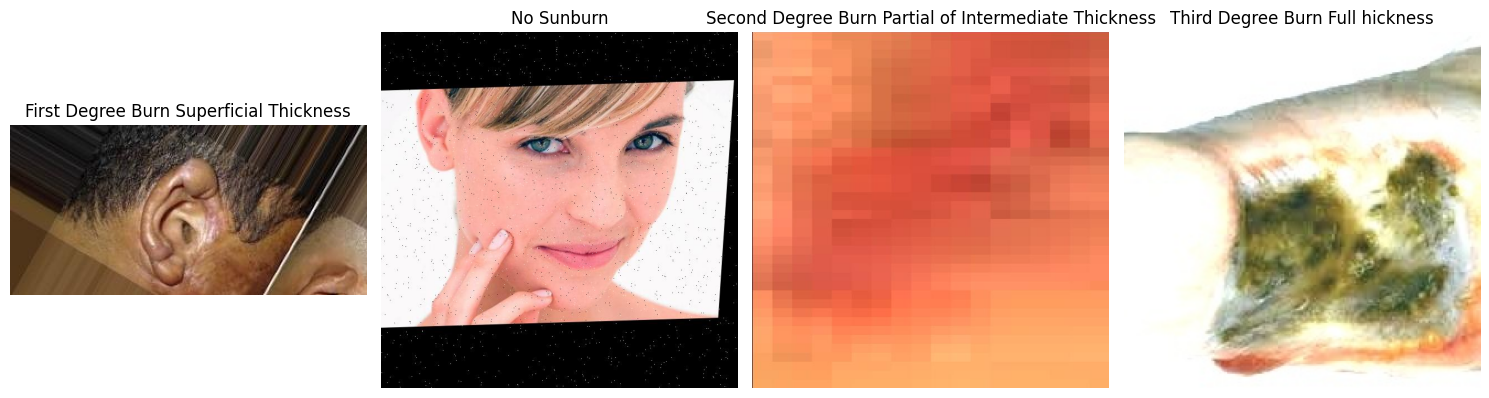

In [43]:
import os
import cv2
import matplotlib.pyplot as plt
import random

def show_one_image_per_class(train_path):
    class_names = sorted(os.listdir(train_path))

    plt.figure(figsize=(15, 5))

    for i, class_name in enumerate(class_names):
        class_folder = os.path.join(train_path, class_name)

        if not os.path.isdir(class_folder):
            continue

        images = []
        for file in os.listdir(class_folder):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images.append(os.path.join(class_folder, file))

        if len(images) == 0:
            continue

        img_path = random.choice(images)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(class_names), i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_one_image_per_class(TRAIN_PATH)

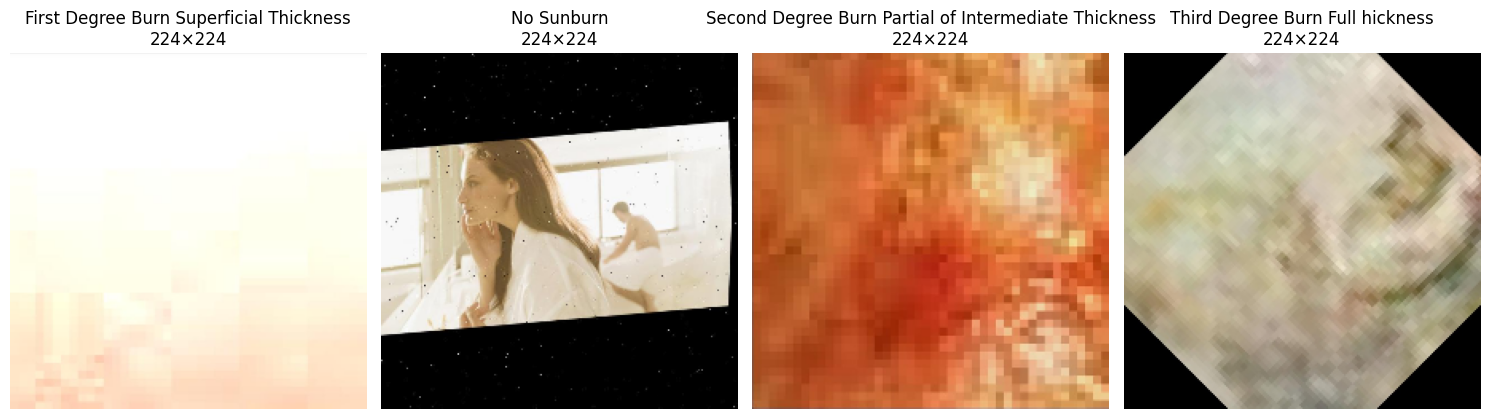

In [44]:
import os
import cv2
import matplotlib.pyplot as plt
import random

def show_one_image_per_class(train_path):
    class_names = sorted(os.listdir(train_path))

    plt.figure(figsize=(15, 5))

    for i, class_name in enumerate(class_names):
        class_folder = os.path.join(train_path, class_name)

        if not os.path.isdir(class_folder):
            continue

        images = []
        for file in os.listdir(class_folder):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images.append(os.path.join(class_folder, file))

        if len(images) == 0:
            continue

        img_path = random.choice(images)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ✅ RESIZE TO 224x224
        img = cv2.resize(img, (224, 224))

        plt.subplot(1, len(class_names), i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
        plt.title(f"{class_name}\n224×224")

    plt.tight_layout()
    plt.show()

show_one_image_per_class(TRAIN_PATH)

In [50]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt

In [86]:
def show_hybrid_segmentation(image_path):
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    mask = hybrid_skin_mask(img)
    segmented = cv2.bitwise_and(img, img, mask=mask)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original (224×224)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Hybrid Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(segmented)
    plt.title("Segmented")
    plt.axis("off")

    plt.show()

In [92]:
import cv2
import numpy as np

def lab_burn_mask(image):
    # Convert RGB → LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0]
    A = lab[:, :, 1]
    B = lab[:, :, 2]

    # Normalize (optional but improves stability)
    L = L / 255.0
    A = A / 255.0
    B = B / 255.0

    # -----------------------------
    # BURN RULE (heuristic)
    # -----------------------------
    burn_mask = (
        (A > 0.55) &      # strong redness
        (L > 0.2) & (L < 0.85)  # avoid extreme dark/light regions
    )

    return (burn_mask.astype(np.uint8) * 255)

import os, random

def get_random_image(path):
    imgs = []
    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(('.jpg','.png','.jpeg')):
                imgs.append(os.path.join(root, f))
    return random.choice(imgs)

import matplotlib.pyplot as plt

def show_lab_burn_segmentation(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    mask = lab_burn_mask(img)

    segmented = cv2.bitwise_and(img, img, mask=mask)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original (224×224)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("LAB Burn Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(segmented)
    plt.title("Burn Segmented (LAB*)")
    plt.axis("off")

    plt.show()

In [95]:
def show_pipeline(train_path):

    # Step 1: Load image
    img_path = get_random_image(train_path)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Step 2: LAB mask
    raw_mask = lab_burn_mask(img)

    # Step 3: Morphology
    clean_mask = post_process_mask(raw_mask)

    # Step 4: Segmentation
    raw_seg = cv2.bitwise_and(img, img, mask=raw_mask)
    clean_seg = cv2.bitwise_and(img, img, mask=clean_mask)

    # Step 5: Plot
    plt.figure(figsize=(12,6))

    plt.subplot(2,2,1)
    plt.imshow(img)
    plt.title("Original (224×224)")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(raw_mask, cmap="gray")
    plt.title("Raw LAB Mask")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("After Morphology")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(clean_seg)
    plt.title("Final Burn Segmentation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [101]:
def post_process_mask(mask):
    kernel = np.ones((5,5), np.uint8)

    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)

    return closed

In [ ]:
def extract_region(image, mask):
    # ensure mask is binary
    mask = (mask > 0).astype(np.uint8) * 255

    # extract region
    extracted = cv2.bitwise_and(image, image, mask=mask)

    return extracted

def show_region_extraction(train_path):
    img_path = get_random_image(train_path)

    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Step 1: LAB mask
    raw_mask = lab_burn_mask(img)

    # Step 2: Morphology
    clean_mask = post_process_mask(raw_mask)

    # Step 3: Region extraction
    extracted = extract_region(img, clean_mask)

    # Plot
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("Final Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(extracted)
    plt.title("Extracted Region")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
show_region_extraction(TRAIN_PATH)

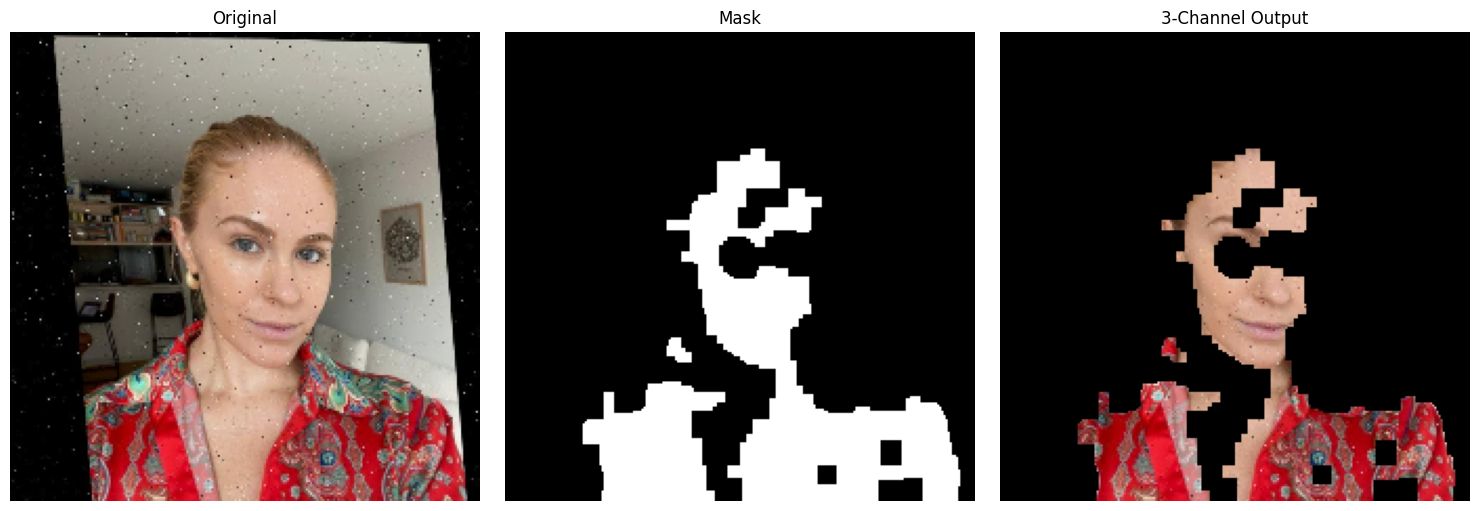

In [104]:
import cv2
import numpy as np

def extract_3channel_region(image, mask):
    # ensure binary mask
    mask = (mask > 0).astype(np.uint8)

    # expand mask to 3 channels
    mask_3ch = np.stack([mask, mask, mask], axis=-1)

    # apply mask
    output = image * mask_3ch

    return output

import matplotlib.pyplot as plt

def show_3channel_pipeline(train_path):
    img_path = get_random_image(train_path)

    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # LAB segmentation
    raw_mask = lab_burn_mask(img)

    # Morphology cleanup
    clean_mask = post_process_mask(raw_mask)

    # 3-channel output
    extracted_3ch = extract_3channel_region(img, clean_mask)

    # Visualization
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(extracted_3ch)
    plt.title("3-Channel Output")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_3channel_pipeline(TRAIN_PATH)

In [122]:
def full_pipeline_fast():

    print("Loading image...")

    img_path = get_random_image_fast()

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))  # keep ONLY this resize

    # --- Step 2: Skin Mask ---
    skin = skin_mask(img)

    # --- Step 3: Burn Mask ---
    burn = burn_mask(img)

    # --- Step 4: Clean ---
    skin = clean(skin)
    burn = clean(burn)

    # --- Step 5: Combine ---
    combined = combine(skin, burn)

    # --- Step 6: Extract ---
    final = extract(img, combined)

    # --- Display ---
    plt.figure(figsize=(18,6))

    plt.subplot(1,5,1)
    plt.imshow(img)
    plt.title("Resized")
    plt.axis("off")

    plt.subplot(1,5,2)
    plt.imshow(skin, cmap="gray")
    plt.title("Skin Mask")
    plt.axis("off")

    plt.subplot(1,5,3)
    plt.imshow(burn, cmap="gray")
    plt.title("Burn Mask")
    plt.axis("off")

    plt.subplot(1,5,4)
    plt.imshow(combined, cmap="gray")
    plt.title("Combined")
    plt.axis("off")

    plt.subplot(1,5,5)
    plt.imshow(final)
    plt.title("Final Output")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [130]:
TRAIN_PATH = "/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split/train"
TEST_PATH  = "/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split/test"

In [131]:
# -------------------------------
# IMPORTS
# -------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision.models import resnet50, ResNet50_Weights

import cv2
import os
import numpy as np

# -------------------------------
# 🔥 YOUR FUNCTIONS (must exist)
# -------------------------------
# skin_mask(img)
# burn_mask(img)
# clean(mask)
# combine(skin, burn)

# -------------------------------
# DATASET CLASS
# -------------------------------
class BurnDataset(Dataset):
    def __init__(self, root_dir):
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(root_dir))

        valid_ext = ('.jpg', '.jpeg', '.png')

        for label, cls in enumerate(self.classes):
            cls_path = os.path.join(root_dir, cls)

            if not os.path.isdir(cls_path):
                continue

            for img_name in os.listdir(cls_path):
                if img_name.lower().endswith(valid_ext):
                    self.image_paths.append(os.path.join(cls_path, img_name))
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)

        # ✅ Handle bad images
        if img is None:
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # 🔥 YOUR PIPELINE
            try:
                skin = clean(skin_mask(img))
                burn = clean(burn_mask(img))
                combined = combine(skin, burn)

                coords = cv2.findNonZero(combined.astype(np.uint8))

                if coords is not None:
                    x, y, w, h = cv2.boundingRect(coords)
                    img = img[y:y+h, x:x+w]

            except:
                pass

        # Resize
        img = cv2.resize(img, (224, 224))

        # Normalize
        img = img / 255.0
        img = np.transpose(img, (2, 0, 1))

        label = self.labels[idx]

        return torch.tensor(img, dtype=torch.float32), torch.tensor(label)


# -------------------------------
# 🔥 DATA PATHS
# -------------------------------
base_path = "/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split"

train_path = os.path.join(base_path, "train")
val_path   = os.path.join(base_path, "test")

# -------------------------------
# LOAD DATASETS
# -------------------------------
train_dataset = BurnDataset(train_path)
val_dataset   = BurnDataset(val_path)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

# -------------------------------
# DATALOADER
# -------------------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32,shuffle=False)

# -------------------------------
# MODEL
# -------------------------------
model = resnet50(weights=ResNet50_Weights.DEFAULT)

num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# -------------------------------
# LOSS & OPTIMIZER
# -------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# -------------------------------
# 🔥 EARLY STOPPING SETUP
# -------------------------------
num_epochs = 100
best_val_loss = float('inf')
patience = 10
counter = 0

# -------------------------------
# TRAINING LOOP
# -------------------------------
for epoch in range(num_epochs):

    # ---- TRAIN ----
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = correct / total
    train_loss = train_loss / len(train_loader)

    # ---- VALIDATION ----
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = correct / total
    val_loss = val_loss / len(val_loader)

    # ---- PRINT ----
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 50)

    # ---- EARLY STOPPING ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        # Save best model
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print("✅ Best model saved!")

    else:
        counter += 1
        print(f"⚠️ No improvement for {counter} epochs")

        if counter >= patience:
            print("🛑 Early stopping triggered!")
            break


# -------------------------------
# FINAL SAVE (optional)
# -------------------------------
torch.save(model.state_dict(), "/kaggle/working/final_model.pth")

print("✅ Training complete!")

Train size: 10817
Val size: 2323
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s] 



Epoch [1/100]
Train Loss: 0.5474 | Train Acc: 0.7862
Val   Loss: 0.3454 | Val   Acc: 0.8696
--------------------------------------------------
✅ Best model saved!

Epoch [2/100]
Train Loss: 0.2643 | Train Acc: 0.9013
Val   Loss: 0.2972 | Val   Acc: 0.8859
--------------------------------------------------
✅ Best model saved!

Epoch [3/100]
Train Loss: 0.1678 | Train Acc: 0.9406
Val   Loss: 0.2789 | Val   Acc: 0.8988
--------------------------------------------------
✅ Best model saved!

Epoch [4/100]
Train Loss: 0.1200 | Train Acc: 0.9579
Val   Loss: 0.2849 | Val   Acc: 0.9027
--------------------------------------------------
⚠️ No improvement for 1 epochs

Epoch [5/100]
Train Loss: 0.0938 | Train Acc: 0.9672
Val   Loss: 0.3073 | Val   Acc: 0.9031
--------------------------------------------------
⚠️ No improvement for 2 epochs

Epoch [6/100]
Train Loss: 0.0868 | Train Acc: 0.9717
Val   Loss: 0.2998 | Val   Acc: 0.9079
--------------------------------------------------
⚠️ No improvem

In [263]:
import time

In [266]:
train_end_time = time.time()
train_time = train_end_time - train_start_time

print(f"\n⏱️ Total Training Time: {train_time:.2f} seconds")


⏱️ Total Training Time: 152.78 seconds


In [268]:
if torch.cuda.is_available():
    torch.cuda.synchronize()

gpu_start = time.time()

test_accuracy = evaluate(test_loader)

if torch.cuda.is_available():
    torch.cuda.synchronize()

gpu_end = time.time()

gpu_time = gpu_end - gpu_start

print(f"🚀 GPU Inference Time: {gpu_time:.4f} seconds")

🚀 GPU Inference Time: 14.9485 seconds


In [157]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 14))

# From your logs
train_losses = [0.5474, 0.2643, 0.1678, 0.1200, 0.0938, 0.0868, 0.0643, 0.0599, 0.0576, 0.0530, 0.0496, 0.0667, 0.0568]
val_losses   = [0.3454, 0.2972, 0.2789, 0.2849, 0.3073, 0.2998, 0.3166, 0.3240, 0.3439, 0.3341, 0.4002, 0.4241, 0.3544]

train_acc = [0.7862, 0.9013, 0.9406, 0.9579, 0.9672, 0.9717, 0.9775, 0.9777, 0.9787, 0.9801, 0.9809, 0.9763, 0.9776]
val_acc   = [0.8696, 0.8859, 0.8988, 0.9027, 0.9031, 0.9079, 0.9087, 0.9139, 0.9044, 0.9057, 0.8963, 0.8954, 0.9036]

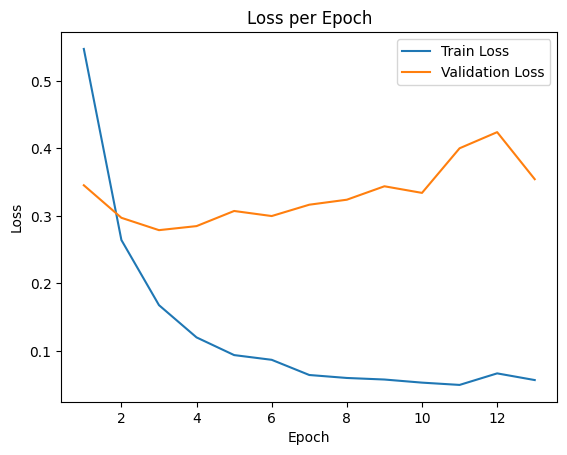

In [158]:
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()
plt.show()

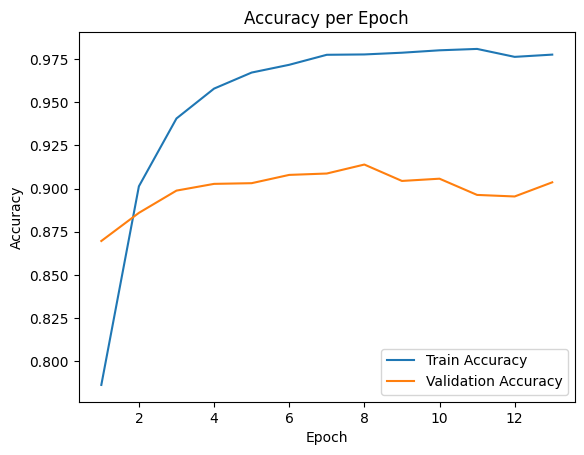

In [159]:
plt.figure()
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy per Epoch")
plt.legend()
plt.show()

In [135]:
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Confusion Matrix:
 [[405   0  87   4]
 [  0 148   0   0]
 [ 30   2 890  37]
 [  8   0  67 645]]


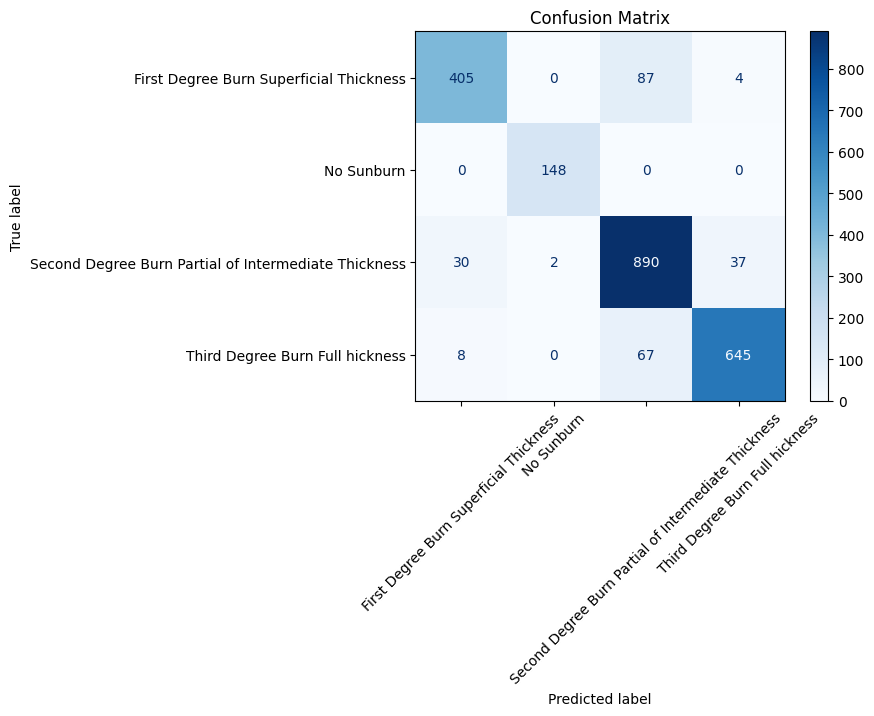


📊 Evaluation Metrics:
Precision: 0.9014
Recall:    0.8988
F1 Score:  0.8987

📋 Classification Report:
                                                      precision    recall  f1-score   support

             First Degree Burn Superficial Thickness       0.91      0.82      0.86       496
                                          No Sunburn       0.99      1.00      0.99       148
Second Degree Burn Partial of Intermediate Thickness       0.85      0.93      0.89       959
                     Third Degree Burn Full hickness       0.94      0.90      0.92       720

                                            accuracy                           0.90      2323
                                           macro avg       0.92      0.91      0.92      2323
                                        weighted avg       0.90      0.90      0.90      2323



In [160]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import matplotlib.pyplot as plt

# -------------------------------
# EVALUATION
# -------------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# -------------------------------
# CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# METRICS
# -------------------------------

precision = precision_score(all_labels, all_preds, average='weighted')
recall    = recall_score(all_labels, all_preds, average='weighted')
f1        = f1_score(all_labels, all_preds, average='weighted')

print("\n📊 Evaluation Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# -------------------------------
# DETAILED REPORT (BEST)
# -------------------------------
print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Normalized Confusion Matrix:
 [[0.81653226 0.         0.17540323 0.00806452]
 [0.         1.         0.         0.        ]
 [0.03128259 0.00208551 0.92805005 0.03858186]
 [0.01111111 0.         0.09305556 0.89583333]]


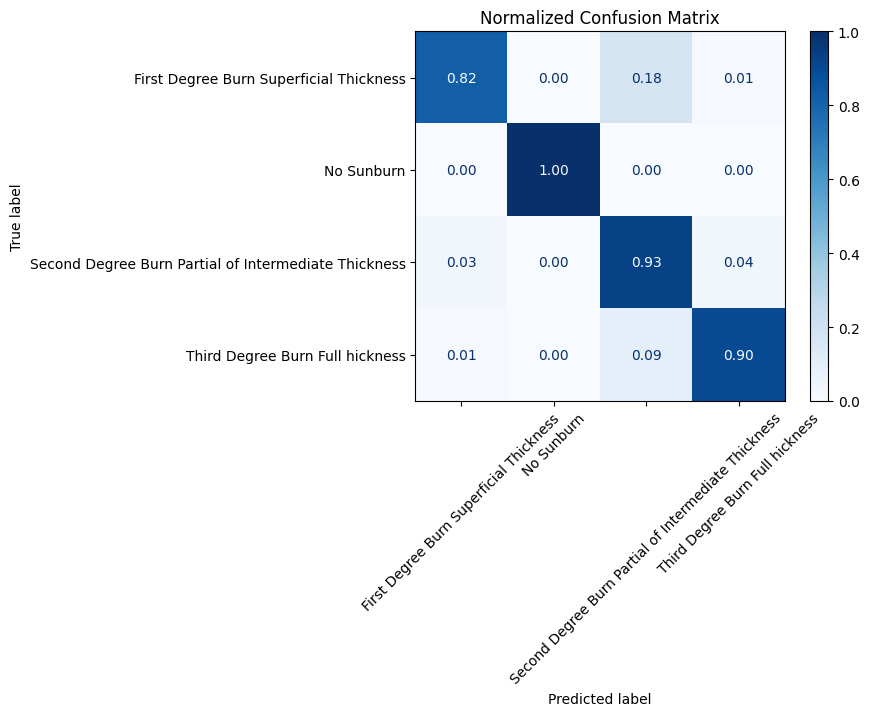

In [162]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# NORMALIZED CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(all_labels, all_preds)

# Normalize (row-wise)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print("Normalized Confusion Matrix:\n", cm_normalized)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=train_dataset.classes
)

disp.plot(cmap="Blues", values_format=".2f", xticks_rotation=45)
plt.title("Normalized Confusion Matrix")
plt.show()


Per-Class Accuracy:
First Degree Burn Superficial Thickness: 0.8165
No Sunburn: 1.0000
Second Degree Burn Partial of Intermediate Thickness: 0.9281
Third Degree Burn Full hickness: 0.8958


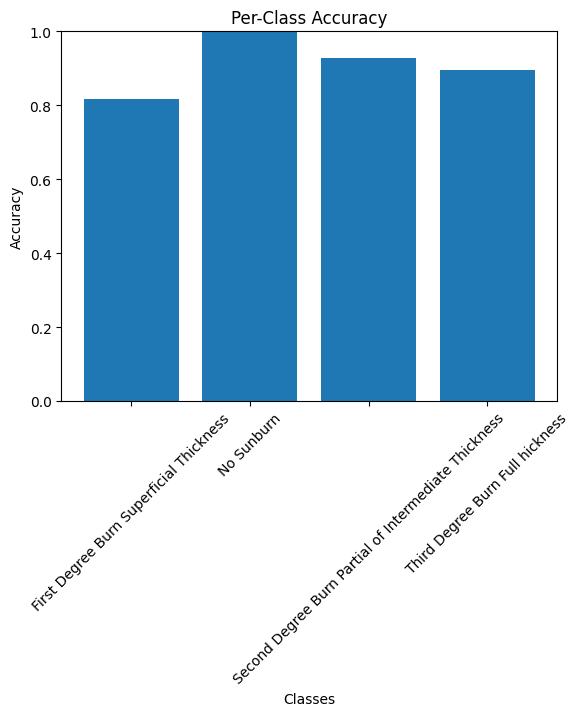

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# -------------------------------
# CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(all_labels, all_preds)

# -------------------------------
# PER-CLASS ACCURACY
# -------------------------------
class_totals = cm.sum(axis=1)
class_correct = np.diag(cm)

per_class_accuracy = class_correct / class_totals

# Print results
print("\nPer-Class Accuracy:")
for i, acc in enumerate(per_class_accuracy):
    print(f"{train_dataset.classes[i]}: {acc:.4f}")

# -------------------------------
# PLOT GRAPH
# -------------------------------
plt.figure()

plt.bar(train_dataset.classes, per_class_accuracy)
plt.xlabel("Classes")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.xticks(rotation=45)

plt.ylim(0, 1)  # accuracy range

plt.show()

In [185]:
train_full = BurnDataset("/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split/train")
test_dataset = BurnDataset("/kaggle/input/datasets/dhirajkumarbalamanik/skin-burn/dataset_split/test")

# Split train into train + validation
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(train_full, [train_size, val_size])

In [187]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32,shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [202]:
def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total

In [203]:
train_acc = evaluate_accuracy(model, train_loader)
val_acc   = evaluate_accuracy(model, val_loader)
test_acc  = evaluate_accuracy(model, test_loader)

print("\n📊 Final Accuracy Results:")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val   Accuracy: {val_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")


📊 Final Accuracy Results:
Train Accuracy: 0.9815
Val   Accuracy: 0.9764
Test  Accuracy: 0.8988


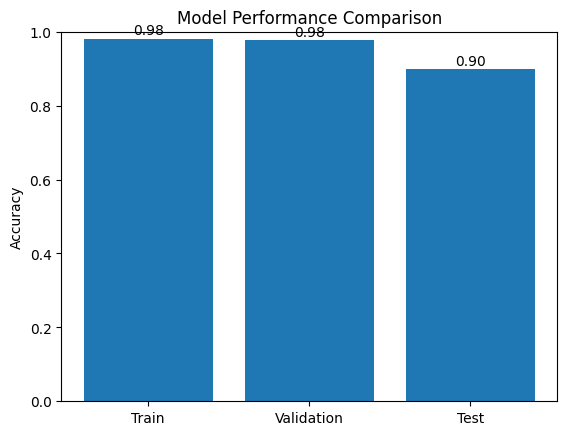

In [206]:
import matplotlib.pyplot as plt

datasets = ["Train", "Validation", "Test"]
accuracies = [train_acc, val_acc, test_acc]

plt.figure()
plt.bar(datasets, accuracies)

plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

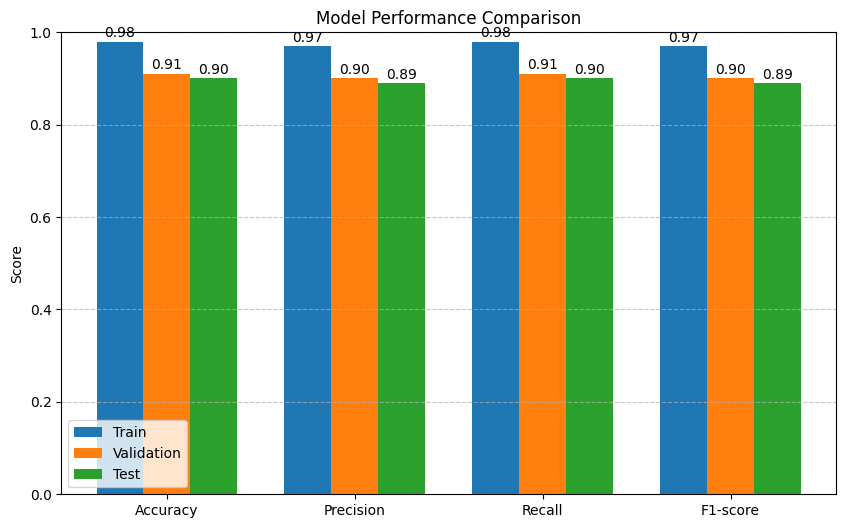

In [210]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# LABELS
# -------------------------
labels = ["Accuracy", "Precision", "Recall", "F1-score"]

# -------------------------
# YOUR METRICS (example values — replace with yours)
# -------------------------
train_metrics = [0.98, 0.97, 0.98, 0.97]
val_metrics   = [0.91, 0.90, 0.91, 0.90]
test_metrics  = [0.90, 0.89, 0.90, 0.89]

train_values = list(train_metrics)
val_values   = list(val_metrics)
test_values  = list(test_metrics)

x = np.arange(len(labels))
width = 0.25

# -------------------------
# BAR PLOT
# -------------------------
plt.figure(figsize=(10,6))

plt.bar(x - width, train_values, width, label="Train")
plt.bar(x,         val_values,   width, label="Validation")
plt.bar(x + width, test_values, width, label="Test")

# Labels
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

# Show values on bars
for i in range(len(labels)):
    plt.text(x[i] - width, train_values[i] + 0.01, f"{train_values[i]:.2f}", ha='center')
    plt.text(x[i],         val_values[i] + 0.01,   f"{val_values[i]:.2f}", ha='center')
    plt.text(x[i] + width, test_values[i] + 0.01,  f"{test_values[i]:.2f}", ha='center')

plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


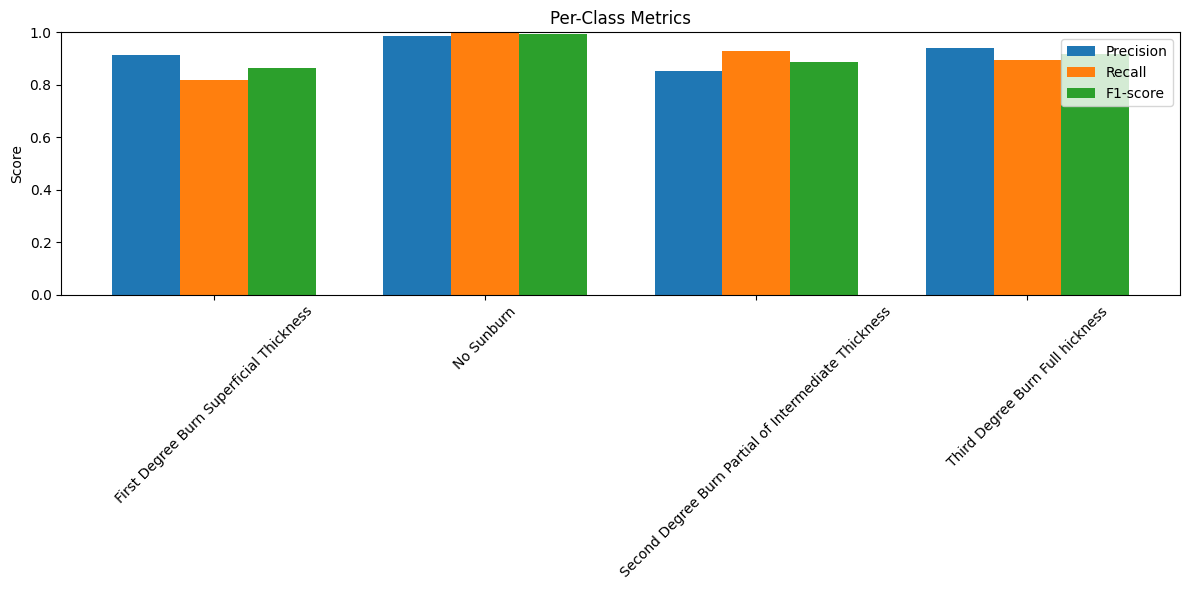

In [211]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# ✅ FIX HERE
classes = train_dataset.dataset.classes

report = classification_report(
    all_labels,
    all_preds,
    target_names=classes,
    output_dict=True
)

precision, recall, f1 = [], [], []

for cls in classes:
    precision.append(report[cls]['precision'])
    recall.append(report[cls]['recall'])
    f1.append(report[cls]['f1-score'])

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x,         recall,    width, label='Recall')
plt.bar(x + width, f1,        width, label='F1-score')

plt.xticks(x, classes, rotation=45)
plt.ylabel("Score")
plt.title("Per-Class Metrics")
plt.legend()

plt.ylim(0,1)
plt.tight_layout()
plt.show()

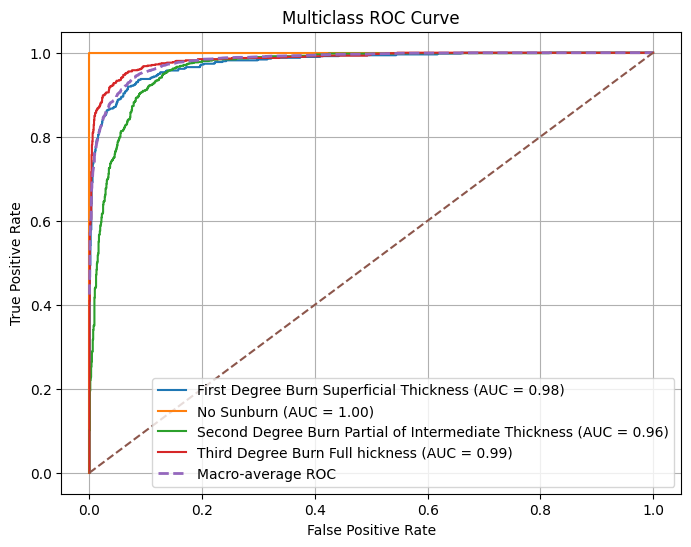

In [212]:
# -------------------------------
# IMPORTS
# -------------------------------
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# -------------------------------
# GET CLASS NAMES (FIX FOR SUBSET)
# -------------------------------
try:
    classes = train_dataset.dataset.classes   # if using random_split
except:
    classes = train_dataset.classes           # if not split

n_classes = len(classes)

# -------------------------------
# COLLECT PROBABILITIES
# -------------------------------
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:   # use test_loader or val_loader
        images = images.to(device)

        outputs = model(images)

        # 🔥 Convert logits → probabilities
        probs = torch.softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# -------------------------------
# BINARIZE LABELS
# -------------------------------
y_true = label_binarize(all_labels, classes=range(n_classes))

# -------------------------------
# COMPUTE ROC CURVES
# -------------------------------
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# -------------------------------
# MACRO AVERAGE ROC
# -------------------------------
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

# -------------------------------
# PLOT ROC CURVES
# -------------------------------
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})")

# Macro-average
plt.plot(all_fpr, mean_tpr,
         linestyle='--', linewidth=2,
         label="Macro-average ROC")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.grid()

plt.show()

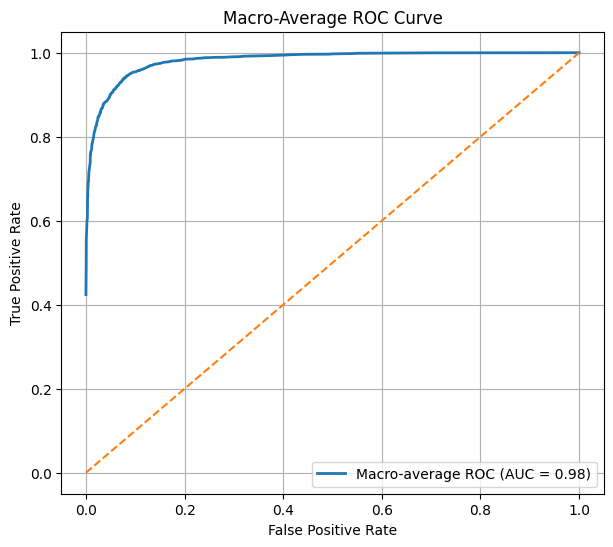

In [213]:
# -------------------------------
# IMPORTS
# -------------------------------
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# -------------------------------
# GET CLASSES (FIX FOR SUBSET)
# -------------------------------
try:
    classes = train_dataset.dataset.classes
except:
    classes = train_dataset.classes

n_classes = len(classes)

# -------------------------------
# COLLECT PROBABILITIES
# -------------------------------
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:   # or val_loader
        images = images.to(device)

        outputs = model(images)

        # Convert logits → probabilities
        probs = torch.softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# -------------------------------
# BINARIZE LABELS
# -------------------------------
y_true = label_binarize(all_labels, classes=range(n_classes))

# -------------------------------
# COMPUTE ROC FOR EACH CLASS
# -------------------------------
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], all_probs[:, i])

# -------------------------------
# MACRO-AVERAGE ROC
# -------------------------------
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

macro_auc = auc(all_fpr, mean_tpr)

# -------------------------------
# PLOT ONLY MACRO ROC
# -------------------------------
plt.figure(figsize=(7,6))

plt.plot(all_fpr, mean_tpr,
         linewidth=2,
         label=f"Macro-average ROC (AUC = {macro_auc:.2f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve")
plt.legend()
plt.grid()

plt.show()

In [254]:
import time

In [260]:
test_start_time = time.time()

test_accuracy = evaluate(test_loader)

test_end_time = time.time()
test_time = test_end_time - test_start_time

print(f"⏱️ Test Time: {test_time:.2f} seconds")

⏱️ Test Time: 15.25 seconds


In [267]:
if torch.cuda.is_available():
    torch.cuda.synchronize()

gpu_start = time.time()

test_accuracy = evaluate(test_loader)

if torch.cuda.is_available():
    torch.cuda.synchronize()

gpu_end = time.time()

gpu_time = gpu_end - gpu_start

print(f"🚀 GPU Inference Time: {gpu_time:.4f} seconds")

🚀 GPU Inference Time: 14.9490 seconds


In [273]:
import psutil
import torch

In [278]:
# -------------------------------
# RAM MEMORY
# -------------------------------
ram = psutil.virtual_memory()

total_ram = ram.total / (1024**3)
available_ram = ram.available / (1024**3)
used_ram = ram.used / (1024**3)

print("\n💻 RAM MEMORY")
print("=" * 30)
print(f"Total RAM     : {total_ram:.2f} GB")
print(f"Available RAM : {available_ram:.2f} GB")
print(f"Used RAM      : {used_ram:.2f} GB")


💻 RAM MEMORY
Total RAM     : 31.35 GB
Available RAM : 28.33 GB
Used RAM      : 2.57 GB


In [280]:
# -------------------------------
# GPU MEMORY
# -------------------------------
if torch.cuda.is_available():
    total_gpu = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    reserved_gpu = torch.cuda.memory_reserved(0) / (1024**3)
    allocated_gpu = torch.cuda.memory_allocated(0) / (1024**3)
    free_gpu = total_gpu - reserved_gpu

    print("\n🚀 GPU MEMORY")
    print("=" * 30)
    print(f"Total GPU Memory : {total_gpu:.2f} GB")
    print(f"Used (Allocated) : {allocated_gpu:.2f} GB")
    print(f"Reserved Memory  : {reserved_gpu:.2f} GB")
    print(f"Free GPU Memory  : {free_gpu:.2f} GB")
else:
    print("\n⚠️ No GPU available")


🚀 GPU MEMORY
Total GPU Memory : 14.56 GB
Used (Allocated) : 0.39 GB
Reserved Memory  : 3.16 GB
Free GPU Memory  : 11.40 GB


In [282]:
torch.save(model.state_dict(), "/kaggle/working/best_model.pth")

In [284]:
torch.save(model.state_dict(), "/kaggle/working/final_model.pth")
print("✅ Final model saved!")

✅ Final model saved!


In [285]:
torch.save(model, "/kaggle/working/full_model.pth")

In [286]:
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': val_loss,
}, "/kaggle/working/checkpoint.pth")

print("✅ Checkpoint saved!")

✅ Checkpoint saved!
